In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =========================
# Parameters
# =========================
g = 1.  # init 1.5
lam = 0.  # init 0.5
rmin = 1e-3
rmax = 20.0
N = 2000

r = np.linspace(rmin, rmax, N)
h = r[1] - r[0]

In [3]:
# =========================
# Yukawa potential
# =========================
def V(r):
    return -g * np.exp(-lam * r) / r

# l = 0 effective potential
Veff = V(r)

In [4]:
# =========================
# Finite-difference Hamiltonian
# H u = E u
# with u(0)=u(rmax)=0 approximately
# =========================
main = np.full(N, 1.0 / h**2) + Veff
off  = np.full(N - 1, -0.5 / h**2)

H = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

In [5]:
# =========================
# Solve eigenvalue problem
# =========================
E, U = np.linalg.eigh(H)

# Keep only bound states
bound = E < 0
E_bound = E[bound]
U_bound = U[:, bound]

if len(E_bound) == 0:
    raise RuntimeError("No bound states found. Try larger g or smaller lam.")

# Ground state: lowest energy
E0 = E_bound[0]
u0 = U_bound[:, 0]

# Normalize: ∫|u|^2 dr = 1
u0 /= np.sqrt(np.trapezoid(u0**2, r))

# Fix sign for prettier plotting
if u0[1] < 0:
    u0 = -u0

R0 = u0 / r
P0 = r**2 * np.abs(R0)**2

print(f"Ground-state energy: E0 = {E0:.6f}")
print(f"Number of bound states found: {len(E_bound)}")

Ground-state energy: E0 = -0.525051
Number of bound states found: 3


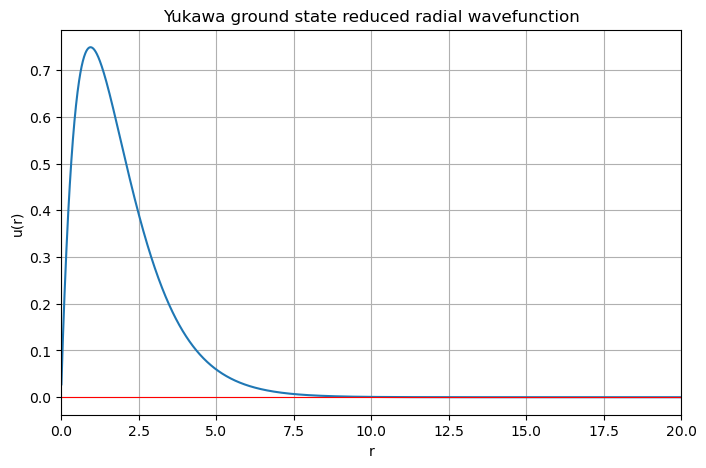

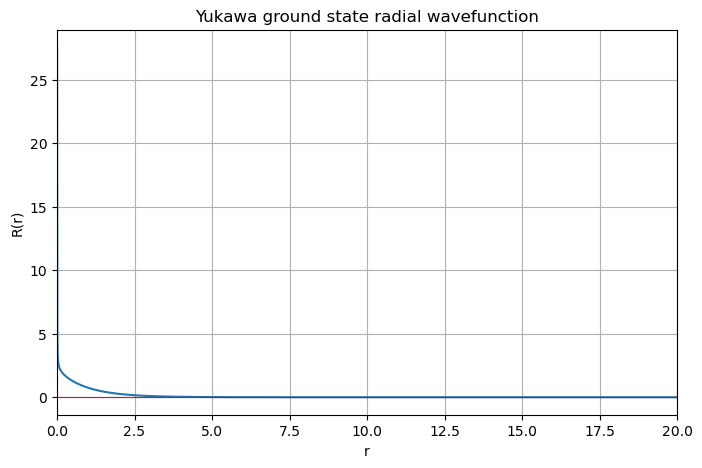

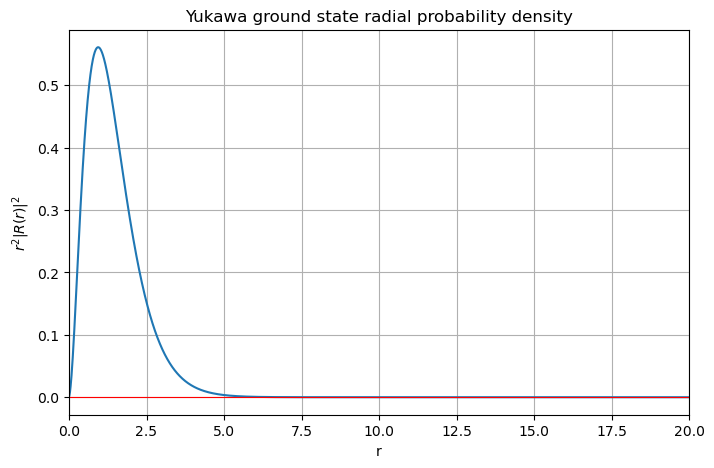

In [6]:
# =========================
# Plot reduced radial wavefunction
# =========================
plt.figure(figsize=(8,5))
plt.plot(r, u0)
plt.axhline(0, linewidth=0.8, color='r', linestyle='-')
plt.xlim(0, rmax)
plt.xlabel("r")
plt.ylabel("u(r)")
plt.title("Yukawa ground state reduced radial wavefunction")
plt.grid(True)
plt.show()

# =========================
# Plot radial wavefunction
# =========================
plt.figure(figsize=(8,5))
plt.plot(r, R0)
plt.axhline(0, linewidth=0.8, color='r', linestyle='-')
plt.xlim(0, rmax)
plt.xlabel("r")
plt.ylabel("R(r)")
plt.title("Yukawa ground state radial wavefunction")
plt.grid(True)
plt.show()

# =========================
# Plot radial probability density
# =========================
plt.figure(figsize=(8,5))
plt.plot(r, P0)
plt.axhline(0, linewidth=0.8, color='r', linestyle='-')
plt.xlim(0, rmax)
plt.xlabel("r")
plt.ylabel(r"$r^2 |R(r)|^2$")
plt.title("Yukawa ground state radial probability density")
plt.grid(True)
plt.show()